# 2023-09 SPX local-volatility and hedging pilot

Explore every available 2023-09 calibration date, then inspect the saved
one-session hedge comparison and attribution. This is a development sample
with provisional contract identity and snapshot provenance.

**Original AH implied volatility** comes from the calibrated price curve.
**Hedge-diffusion local volatility** includes the accepted first-period
variance smoothing. These are different models. Calibration fit and
numerical sensitivity do not establish out-of-sample hedge superiority.

Run the cells in order. Change `DATE` to explore another date. This notebook
loads saved models and results; it performs no optimizer or hedge PDE run.


In [1]:
from pathlib import Path
from functools import lru_cache
import hashlib
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "src").is_dir() and (p / "data").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError("Open this notebook inside local-vol-spx.")
sys.path.insert(0, str(ROOT / "src"))
from andreasen_huge import AndreasenHugeSurface
from daily_ah_validation import AHShortEndVariance

pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.2, "font.size": 10})


In [2]:
RUN_PATHS = {'calibration': '/Users/pranayvij/GitHub/local-vol-spx/data/processed/hedging_pilot/september_2023/daily_ah/run_20261007T040538_966878Z', 'panel': '/Users/pranayvij/GitHub/local-vol-spx/data/processed/hedging_pilot/september_2023/hedge_panel/run_20261007T062726_950243Z', 'comparison': '/Users/pranayvij/GitHub/local-vol-spx/outputs/hedging_pilot_diagnostics/september_2023/run_20261007T074506_549964Z', 'attribution': '/Users/pranayvij/GitHub/local-vol-spx/outputs/hedging_pilot_diagnostics/september_2023/attribution/run_20261007T081012_331452Z'}

RUNS = {name: ROOT / path for name, path in RUN_PATHS.items()}
# Explicit run folders keep the notebook tied to reviewed results.
AUDITS = {name: json.loads((path / "audit.json").read_text())
          for name, path in RUNS.items()}
for name in ["panel", "comparison", "attribution"]:
    if AUDITS[name].get("status") != "completed":
        raise ValueError(f"Incomplete {name} run.")

def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def checked_path(run, filename):
    folder = RUNS[run].resolve()
    path = (folder / filename).resolve()
    if not path.is_relative_to(folder):
        raise ValueError("An artifact path leaves its run folder.")
    expected = AUDITS[run].get("output_sha256", {}).get(filename)
    if expected is None or sha256(path) != expected:
        raise ValueError(f"Missing or mismatched checksum: {run}/{filename}")
    return path

def read_table(run, filename):
    return pd.read_csv(checked_path(run, filename))

for child, parent, filenames in [
    ("panel", "calibration", ["audit.json", "model_manifest.csv"]),
    ("comparison", "panel", ["audit.json", "delta_panel.csv"]),
    ("attribution", "comparison",
     ["audit.json", "strategy_results.csv", "paired_results.csv", "coverage.csv"]),
]:
    recorded = AUDITS[child].get("input_sha256", {})
    for filename in filenames:
        digest = sha256(RUNS[parent] / filename)
        if not any(Path(key).name == filename and value == digest
                   for key, value in recorded.items()):
            raise ValueError(f"{child} does not use the selected {parent}/{filename}.")

manifest = read_table("calibration", "model_manifest.csv")
quotes = read_table("calibration", "quote_residuals.csv")
conditioning = read_table("calibration", "conditioning.csv")
shape = read_table("calibration", "shape_checks.csv")
panel = read_table("panel", "delta_panel.csv")
coverage = read_table("comparison", "coverage.csv")
strategies = read_table("comparison", "strategy_results.csv")
summary = read_table("comparison", "summary.csv")
attribution = read_table("attribution", "attribution.csv")
attribution_summary = read_table("attribution", "summary.csv")
daily_attribution = read_table("attribution", "daily_attribution.csv")
groups = read_table("attribution", "group_summary.csv")
leave_one_out = read_table("attribution", "leave_one_date_out.csv")
DATES = sorted(manifest.quote_date.unique())
RADIUS = float(AUDITS["panel"]["settings"]["radius"])
print(f"Verified {len(DATES)} calibration dates, {len(panel)} entries.")
print(f"Saved hedge diffusion radius: {RADIUS:g}; pricing carry: "
      f"{AUDITS['calibration']['carry_case']}.")
display(pd.DataFrame({"run": RUNS.keys(),
                      "folder": [str(p.relative_to(ROOT)) if p.is_relative_to(ROOT)
                                 else str(p) for p in RUNS.values()]}))


Verified 20 calibration dates, 360 entries.
Saved hedge diffusion radius: 0.0005; pricing carry: rate_5pct.


,run,folder
0,calibration,data/processed/hedging_pilot/september_2023/da...
1,panel,data/processed/hedging_pilot/september_2023/he...
2,comparison,outputs/hedging_pilot_diagnostics/september_20...
3,attribution,outputs/hedging_pilot_diagnostics/september_20...


## Assumptions and units

Observed quote marks and vendor index levels remain the historical inputs.
Estimated forwards, fitted surfaces, and hedge deltas are derived quantities.
The index hedge, funding, and fees below are research conventions. No
simulated historical prices or missing-session replacement marks are used.


In [3]:
ca, ha = AUDITS["calibration"], AUDITS["comparison"]
display(pd.DataFrame([
    ("Historical inputs", "Observed option bid/ask and vendor index levels"),
    ("Identity / snapshot provenance", "Unverified; UNKNOWN remains a label"),
    ("Pricing rate", f"Assumed {100 * ca['assumed_annual_rate']:.1f}% annual rate"),
    ("Forward", "Same-date conditional put-call parity estimate"),
    ("Local-volatility model", f"AH; first-period Gaussian variance blend, radius {RADIUS:g}"),
    ("Greek convention", "Physical local-volatility coefficient and original carry fixed"),
    ("Option / hedge units", ha["unit"]),
    ("Holding period", ha["holding"]),
    ("Hedge fills", ha["hedge_execution"]),
    ("Funding", str(ha["settings"])),
    ("Dividend cash", f"{ha['dividend_per_unit']}; not inferred from the pricing yield proxy"),
    ("Evidence scope", "2023-09 development sample; no executable-return or OOS claim"),
], columns=["item", "convention"]))


,item,convention
0,Historical inputs,Observed option bid/ask and vendor index levels
1,Identity / snapshot provenance,Unverified; UNKNOWN remains a label
2,Pricing rate,Assumed 5.0% annual rate
3,Forward,Same-date conditional put-call parity estimate
4,Local-volatility model,"AH; first-period Gaussian variance blend, radi..."
5,Greek convention,Physical local-volatility coefficient and orig...
6,Option / hedge units,Index points per short research option; both m...
7,Holding period,Entry delta held to the next supplied referenc...
8,Hedge fills,Synthetic fractional index fills at its mark. ...
9,Funding,"{'lend_rate': 0.05, 'borrow_rate': 0.05, 'hedg..."


## Coverage and calibration across dates

Counts include unsuccessful or unavailable entries. Calibration residuals
use original half-spreads; shape checks apply to sampled finite-grid prices.
The conditioning table describes the **original AH** nodal coefficient.


,quote_date,root,status,input_expiries,calibration_quotes,rms_half_spreads,outside_original_bands,active_proxy_bounds,sampled_shape_violations
0,2023-09-01,UNKNOWN,fitted,24,2442,0.697207,312,11,0
1,2023-09-05,UNKNOWN,fitted,22,2045,0.294194,12,0,0
2,2023-09-06,UNKNOWN,fitted,23,2231,0.200251,1,0,0
3,2023-09-07,UNKNOWN,fitted,25,2400,0.187503,0,0,0
4,2023-09-08,UNKNOWN,fitted,26,2415,0.174894,0,0,0
5,2023-09-11,UNKNOWN,fitted,26,2279,0.219431,0,0,0
6,2023-09-12,UNKNOWN,fitted,26,2401,0.524138,168,0,0
7,2023-09-13,UNKNOWN,fitted,26,2459,0.191304,1,0,0
8,2023-09-14,UNKNOWN,fitted,27,2515,0.208708,0,0,0
9,2023-09-15,UNKNOWN,fitted,27,2625,0.231881,2,0,0


,increasing_prices,vertical_spread_violations,negative_butterflies,intrinsic_shortfalls,upper_bound_excesses,calendar_violations
quote_date,,,,,,
2023-09-01,0,0,0,0,0,0
2023-09-05,0,0,0,0,0,0
2023-09-06,0,0,0,0,0,0
2023-09-07,0,0,0,0,0,0
2023-09-08,0,0,0,0,0,0
2023-09-11,0,0,0,0,0,0
2023-09-12,0,0,0,0,0,0
2023-09-13,0,0,0,0,0,0
2023-09-14,0,0,0,0,0,0


,original_AH_sampled_peak_lv_pct,unresolved_original_nodal_samples
quote_date,,
2023-09-01,537.855044,0
2023-09-05,189.865245,0
2023-09-06,395.249408,0
2023-09-07,367.921029,0
2023-09-08,288.594164,0
2023-09-11,154.985958,0
2023-09-12,155.068201,0
2023-09-13,250.729463,0
2023-09-14,220.815514,0


entries
scenario          status             
mid               compared        342
                  sample_end       18
option_spread     compared        342
                  sample_end       18
option_spread_fee compared        342
                  sample_end       18

,entries,ready,matched
quote_date,,,
2023-09-01,18,18,18
2023-09-05,18,18,18
2023-09-06,18,18,18
2023-09-07,18,18,18
2023-09-08,18,18,18
2023-09-11,18,18,18
2023-09-12,18,18,18
2023-09-13,18,18,18
2023-09-14,18,18,18


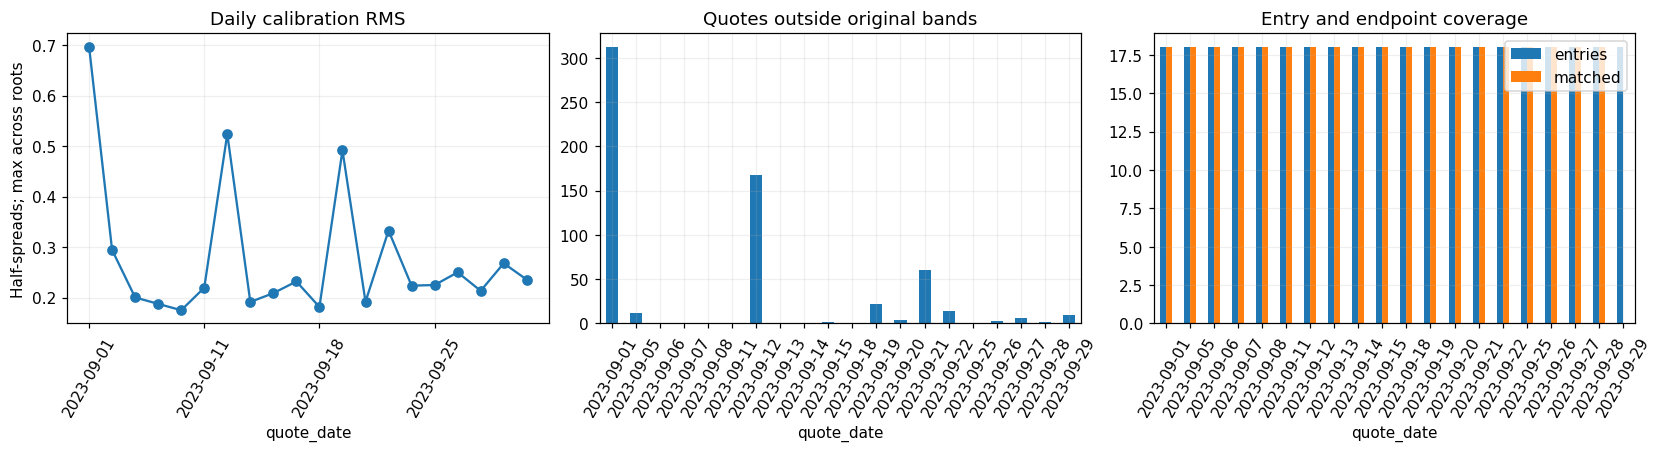

In [4]:
display(manifest[["quote_date", "root", "status", "input_expiries",
                  "calibration_quotes", "rms_half_spreads",
                  "outside_original_bands", "active_proxy_bounds",
                  "sampled_shape_violations"]])
flags = ["increasing_prices", "vertical_spread_violations", "negative_butterflies",
         "intrinsic_shortfalls", "upper_bound_excesses", "calendar_violations"]
display(shape.groupby("quote_date")[flags].sum())
display(conditioning.groupby("quote_date").agg(
    original_AH_sampled_peak_lv_pct=("peak_local_vol_pct", "max"),
    unresolved_original_nodal_samples=("unresolved_variance_nodes", "sum")))
display(coverage.groupby(["scenario", "status"]).size().rename("entries").to_frame())
counts = panel.groupby("quote_date").agg(
    entries=("entry_id", "size"), ready=("both_deltas_ready", "sum"),
    matched=("matched_comparison_available", "sum")).reindex(DATES)
display(counts)
fig, ax = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
fit = manifest.groupby("quote_date").agg(
    rms=("rms_half_spreads", "max"), outside=("outside_original_bands", "sum"))
fit.rms.plot(ax=ax[0], marker="o", title="Daily calibration RMS")
ax[0].set_ylabel("Half-spreads; max across roots")
fit.outside.plot.bar(ax=ax[1], title="Quotes outside original bands")
counts[["entries", "matched"]].plot.bar(ax=ax[2], title="Entry and endpoint coverage")
for a in ax:
    a.tick_params(axis="x", rotation=60)
plt.show()


## Date explorer

`DATE` can be any date printed in `DATES`. Surface maps use
$y=\log(K/F(T))$ over [-0.09, 0.09]. IV starts at the first fitted maturity.
Local volatility includes positive short-end times; day-zero coefficients
are never requested. Pillars use their right-hand coefficient, with the
left-hand value at the terminal pillar. The separate jump table checks
both sides on a denser sample. Sampled peaks are not global maxima.

Local-volatility colors use a logarithmic scale. Values are not capped or
clipped. Blank hedge results mean unavailable observations, not zero P&L.


In [5]:
@lru_cache(maxsize=3)
def load_model(date, root):
    rows = manifest[(manifest.quote_date == date) & (manifest.root == root)]
    if len(rows) != 1 or rows.iloc[0].status != "fitted":
        raise ValueError("Choose one successfully fitted date/root.")
    row = rows.iloc[0]
    path = checked_path("calibration", row.model_file)
    if sha256(path) != row.model_sha256:
        raise ValueError("Model checksum does not match its manifest.")
    model = AndreasenHugeSurface.load(path)
    return model, AHShortEndVariance(model, RADIUS)

@lru_cache(maxsize=3)
def surface_samples(date, root):
    model, diffusion = load_model(date, root)
    y = np.linspace(-0.09, 0.09, 81)
    pillars = model.maturities
    times = np.unique(np.r_[pillars, 0.5 * (pillars[:-1] + pillars[1:])])
    iv = np.array([100 * model.implied_volatility(model.forward(t) * np.exp(y), t)
                   for t in times])
    lv_times = np.unique(np.r_[pillars[0] * np.array([0.0625, 0.25, 0.5]), times])
    lv = np.array([100 * np.sqrt(diffusion.normalized_variance(
        np.exp(y), t, "left" if t == pillars[-1] else "right")) for t in lv_times])
    if not np.isfinite(iv).all() or not np.isfinite(lv).all() or (lv <= 0).any():
        raise ArithmeticError("Surface contains unresolved values.")
    return y, times * 365, iv, lv_times * 365, lv

def explore_day(date, root="UNKNOWN"):
    model, diffusion = load_model(date, root)
    print(f"{date}: spot {model.spot:.2f}; {len(model.maturities)} expiry pillars.")
    q = quotes[(quotes.quote_date == date) & (quotes.root == root)]
    p = panel[(panel.quote_date == date) & (panel.root == root)]
    y, days, iv, lv_days, lv = surface_samples(date, root)
    fig, ax = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
    im = ax[0, 0].pcolormesh(y, days, iv, shading="nearest", cmap="viridis")
    fig.colorbar(im, ax=ax[0, 0], label="Implied vol (%)")
    ax[0, 0].set_title("Original AH calibration implied volatility")
    im = ax[0, 1].pcolormesh(y, lv_days, lv, shading="nearest", cmap="magma",
                           norm=LogNorm(vmin=lv.min(), vmax=lv.max()))
    fig.colorbar(im, ax=ax[0, 1], label="Local vol (%), log scale")
    ax[0, 1].set_title(f"Hedge-diffusion local volatility; radius {RADIUS:g}")
    for a in ax[0]:
        a.set_xlabel("Forward log-moneyness")
        a.set_ylabel("Calendar days remaining")
        a.set_xlim(y[0], y[-1])
    ax[0, 0].set_ylim(days[0], days[-1])
    ax[0, 1].set_ylim(lv_days[0], lv_days[-1])
    scatter = ax[1, 0].scatter(q.forward_log_moneyness, q.residual_half_spreads,
                               c=q.assumed_maturity_years * 365, s=12, alpha=0.65)
    fig.colorbar(scatter, ax=ax[1, 0], label="Calendar days remaining")
    ax[1, 0].axhline(1, color="grey", linestyle="--")
    ax[1, 0].axhline(-1, color="grey", linestyle="--")
    ax[1, 0].set(xlabel="Forward log-moneyness", ylabel="Residual / half-spread",
                 title="Original AH quote residuals")
    if len(p):
        for kind, marker in [("call", "o"), ("put", "s")]:
            ready = p[(p.kind == kind) & p.both_deltas_ready]
            ax[1, 1].scatter(ready.black_delta, ready.ah_delta, marker=marker,
                             label=kind, alpha=0.8)
        lo = min(p.black_delta.min(), p.ah_delta.min())
        hi = max(p.black_delta.max(), p.ah_delta.max())
        if np.isfinite([lo, hi]).all():
            ax[1, 1].plot([lo, hi], [lo, hi], "k--", linewidth=1)
        ax[1, 1].legend()
    else:
        ax[1, 1].text(0.5, 0.5, "No saved hedge entries for this date",
                       ha="center", transform=ax[1, 1].transAxes)
    ax[1, 1].set(xlabel="Black delta", ylabel="AH smoothed-diffusion delta",
                 title="Saved entry deltas")
    fig.suptitle(f"2023-09 pilot: {date}", fontsize=14)
    plt.show()

    jump_y = np.linspace(-0.09, 0.09, 721)
    jumps = []
    for t in model.maturities[:-1]:
        left = 100 * np.sqrt(diffusion.normalized_variance(np.exp(jump_y), t, "left"))
        right = 100 * np.sqrt(diffusion.normalized_variance(np.exp(jump_y), t, "right"))
        index = np.argmax(abs(right - left))
        jumps.append({"days": 365 * t, "left_peak_pct": left.max(),
                      "right_peak_pct": right.max(), "jump_y": jump_y[index],
                      "signed_jump_pp": (right - left)[index]})
    display(pd.DataFrame(jumps))
    if len(p):
        display(p[["expire_date", "strike", "kind", "black_delta", "ah_delta",
                   "ah_gamma", "ah_price_minus_mid", "end_date", "end_status"]])
    outcomes = strategies[(strategies.quote_date == date) & (strategies.root == root)]
    if outcomes.empty:
        print("No matched hedge comparison on this date. Entry coverage is retained above.")
    else:
        display(outcomes.groupby(["scenario", "strategy"]).agg(
            comparisons=("net_pnl", "size"), mean_pnl=("net_pnl", "mean"),
            mae=("net_pnl", lambda v: np.mean(abs(v))),
            rms=("net_pnl", lambda v: np.sqrt(np.mean(v ** 2)))))
    return None


Available calibration dates: ['2023-09-01', '2023-09-05', '2023-09-06', '2023-09-07', '2023-09-08', '2023-09-11', '2023-09-12', '2023-09-13', '2023-09-14', '2023-09-15', '2023-09-18', '2023-09-19', '2023-09-20', '2023-09-21', '2023-09-22', '2023-09-25', '2023-09-26', '2023-09-27', '2023-09-28', '2023-09-29']
2023-09-01: spot 4516.02; 24 expiry pillars.


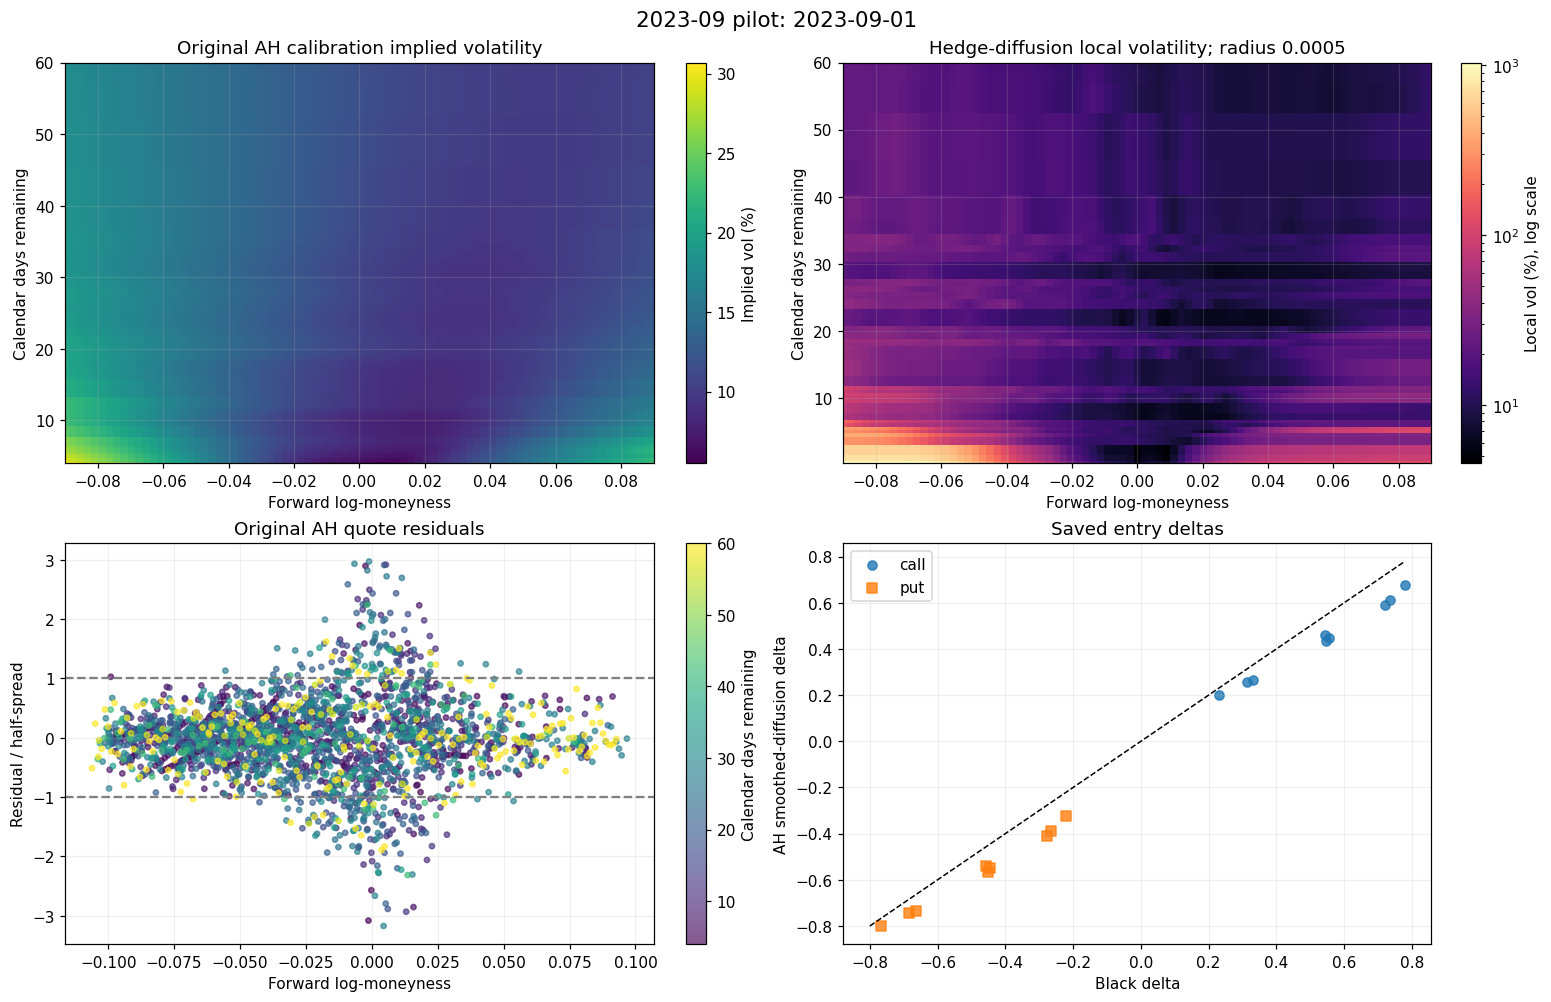

,days,left_peak_pct,right_peak_pct,jump_y,signed_jump_pp
0,4.0,535.986945,300.000000,-0.06300,-363.317618
1,5.0,473.901829,290.862315,-0.08100,-210.688558
2,6.0,413.095256,146.032812,-0.08725,-280.145057
3,7.0,203.414380,63.255161,-0.09000,-140.159219
4,10.0,81.487691,92.257830,0.09000,22.111136
5,11.0,110.000491,93.603905,-0.07975,-33.016930
6,12.0,113.805359,42.349177,-0.09000,-71.456181
7,17.0,54.079605,47.854489,0.09000,-15.129484
8,18.0,52.154429,47.613737,-0.02125,12.325395
9,19.0,55.029535,40.553671,-0.05125,-17.099461


,expire_date,strike,kind,black_delta,ah_delta,ah_gamma,ah_price_minus_mid,end_date,end_status
0,2023-09-22,4425.0,call,0.778972,0.677131,0.011885,0.133127,2023-09-05,matched
1,2023-09-22,4515.0,call,0.542898,0.459949,0.011867,0.174288,2023-09-05,matched
2,2023-09-22,4605.0,call,0.229539,0.199131,0.008518,0.179266,2023-09-05,matched
3,2023-09-22,4425.0,put,-0.219904,-0.322223,0.011885,0.220196,2023-09-05,matched
4,2023-09-22,4515.0,put,-0.456650,-0.539405,0.011867,-0.097175,2023-09-05,matched
5,2023-09-22,4605.0,put,-0.767057,-0.800223,0.008518,-0.200729,2023-09-05,matched
6,2023-10-06,4425.0,call,0.735231,0.610377,0.010708,0.300099,2023-09-05,matched
7,2023-10-06,4515.0,call,0.554905,0.448312,0.010337,0.525704,2023-09-05,matched
8,2023-10-06,4605.0,call,0.314743,0.255477,0.008383,0.059176,2023-09-05,matched
9,2023-10-06,4425.0,put,-0.264790,-0.388839,0.010708,0.053272,2023-09-05,matched


comparisons  mean_pnl       mae        rms
scenario          strategy                                            
mid               ah                 18  3.194792  3.194792   3.620131
                  black              18  1.181012  1.622166   2.002912
                  unhedged           18  1.826082  9.526712  10.443093
option_spread     ah                 18  1.555487  2.405892   2.915529
                  black              18 -0.458293  1.913131   2.399164
                  unhedged           18  0.186777  9.521088  10.454552
option_spread_fee ah                 18  1.105093  2.318162   2.745400
                  black              18 -0.908487  2.058914   2.632434
                  unhedged           18  0.186777  9.521088  10.454552

In [6]:
print("Available calibration dates:", DATES)
DATE = "2023-09-01"
explore_day(DATE)


## Hedge error and attribution

Each observation is a separately opened and liquidated short-option hedge.
These distributions and date contributions are not portfolio wealth curves.
Positive MAE/MSE improvement favors AH. Zero-centered RMS includes P&L bias.
Cost scenarios can offset positive P&L without improving the hedge itself.


,scenario,strategy,comparisons,entry_dates,mean_net_pnl,rms_net_pnl,mean_abs_net_pnl,mean_direct_costs
0,mid,ah,342,19,1.454351,2.740419,2.324998,0.000000
1,mid,black,342,19,0.248993,3.130833,2.359030,0.000000
2,mid,unhedged,342,19,0.647606,17.301511,12.824895,0.000000
3,option_spread,ah,342,19,-0.852883,3.423951,2.658896,2.307018
4,option_spread,black,342,19,-2.058242,4.525753,3.184921,2.307018
5,option_spread,unhedged,342,19,-1.659628,17.876062,12.949192,2.307018
6,option_spread_fee,ah,342,19,-1.293693,3.617159,2.769942,2.747783
7,option_spread_fee,black,342,19,-2.499090,4.794115,3.371060,2.747821
8,option_spread_fee,unhedged,342,19,-1.659628,17.876062,12.949192,2.307018


,scenario,mae_improvement,mse_improvement,variance_improvement,squared_mean_improvement,fraction_ah_lower_abs_error,mean_pnl_gap,mean_delta_exposure,mean_funding_difference,mean_cost_effect,max_identity_residual
0,mid,0.034033,2.292217,4.345357,-2.053140,0.488304,1.205358,1.116308,0.089051,0.000000,1.305622e-12
1,option_spread,0.526025,8.759001,5.250053,3.508948,0.546784,1.205358,1.116308,0.089051,0.000000,9.331425e-13
2,option_spread_fee,0.601118,9.899698,5.327890,4.571809,0.543860,1.205397,1.116308,0.089051,0.000039,1.048217e-12


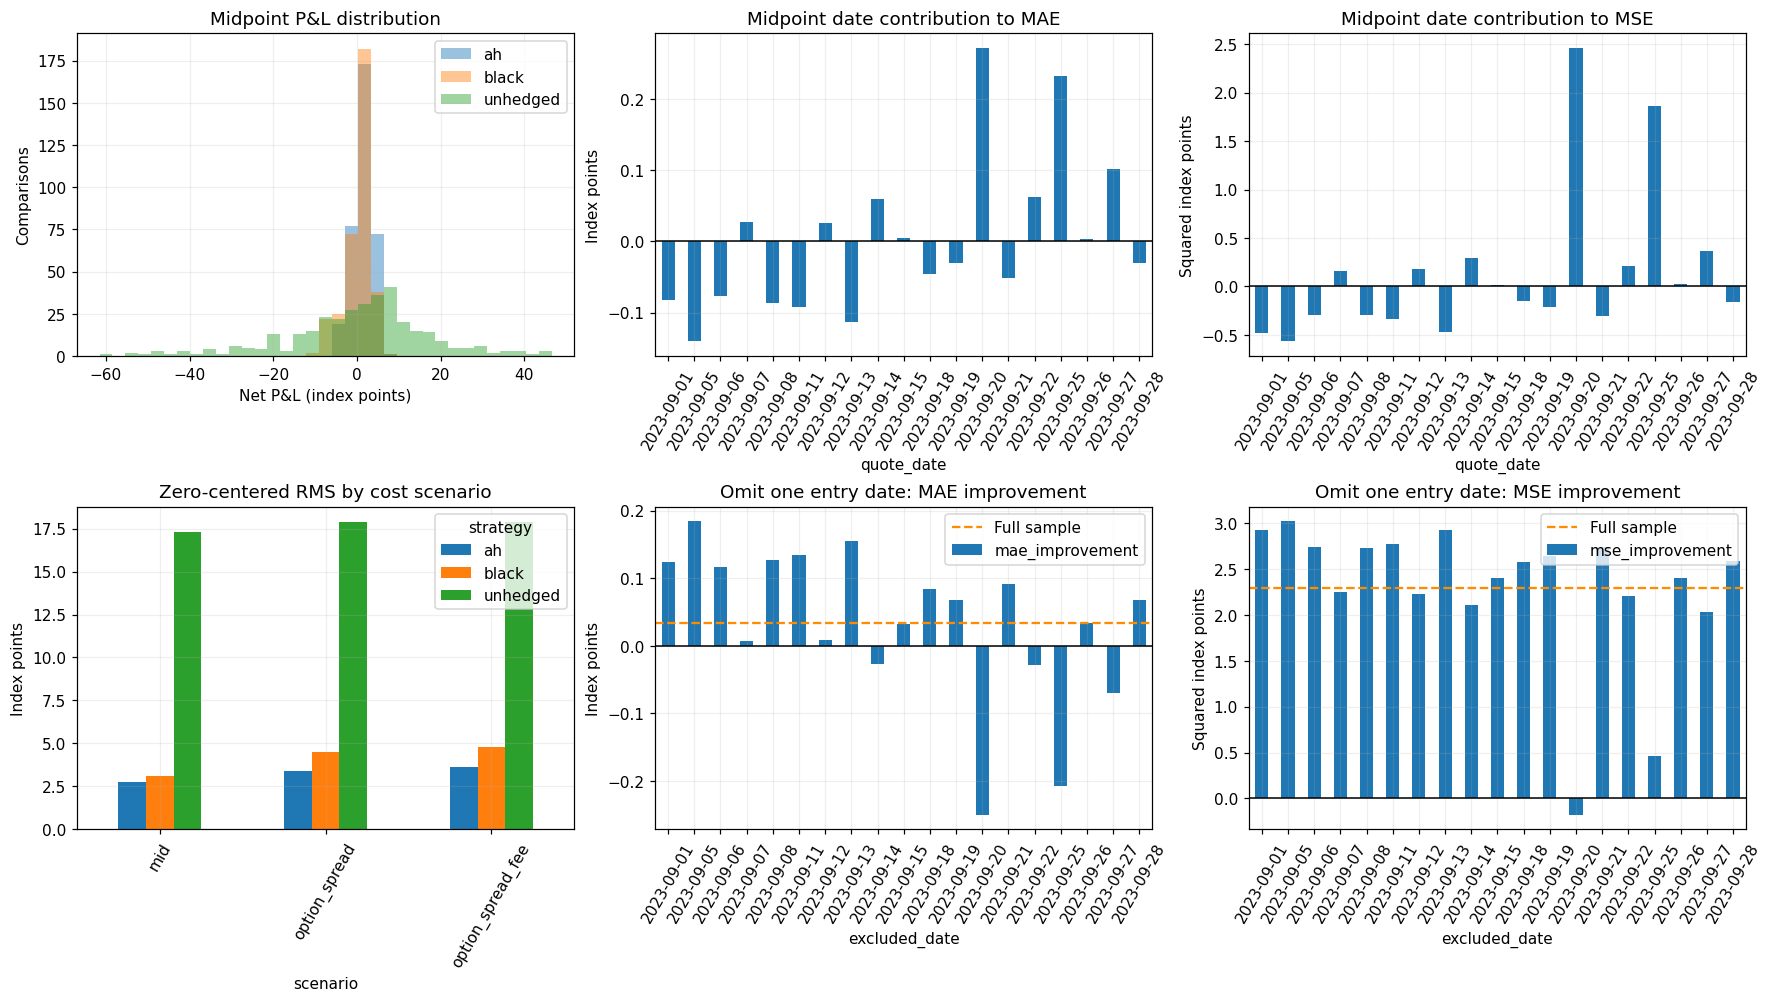

,dimension,group,comparisons,mae_improvement,mse_improvement,fraction_ah_lower_abs_error
0,kind,call,171,0.170859,3.428437,0.485380
1,kind,put,171,-0.102793,1.155998,0.491228
6,maturity_band,14-27d,114,0.248487,3.964276,0.526316
7,maturity_band,28-39d,150,-0.106995,1.952367,0.440000
8,maturity_band,40-45d,78,-0.008192,0.501998,0.525641
15,moneyness_band,K_above_spot,114,0.572558,4.952310,0.596491
16,moneyness_band,K_below_spot,114,-0.561304,-1.120234,0.394737
17,moneyness_band,near_spot,114,0.090844,3.044577,0.473684
24,spot_direction,falling,198,0.017850,3.645326,0.328283
25,spot_direction,rising,144,0.056283,0.431692,0.708333


,scenario,comparisons,entry_dates,ah_mean_pnl,black_mean_pnl,ah_rms,black_rms,ah_mae,black_mae,mae_improvement,...,mean_pnl_gap,mean_delta_exposure,mean_funding_difference,mean_cost_effect,max_identity_residual,spot_change,spot_return,spot_direction,pooled_mae_contribution,pooled_mse_contribution
quote_date,,,,,,,,,,,,,,,,,,,,,
2023-09-20,mid,18,1,-0.785597,-7.177506,2.468056,7.268674,2.027220,7.177506,5.150286,...,6.391909,6.338942,0.052968,0.0,6.997181e-13,-72.17,-0.016395,falling,0.271068,2.460122
2023-09-25,mid,18,1,1.457157,-6.174658,2.260669,6.355552,1.778979,6.174658,4.395679,...,7.631815,7.561936,0.069879,0.0,5.324630e-13,-64.31,-0.014825,falling,0.231352,1.856969
2023-09-27,mid,18,1,0.355980,2.706168,0.913195,2.801615,0.786863,2.706168,1.919305,...,-2.350188,-2.407933,0.057745,0.0,4.056200e-13,24.42,0.005713,rising,0.101016,0.369217
2023-09-14,mid,18,1,1.086857,-3.552242,2.815914,3.682046,2.431083,3.552242,1.121159,...,4.639098,4.587866,0.051233,0.0,1.305622e-12,-55.27,-0.012268,falling,0.059008,0.296216
2023-09-22,mid,18,1,0.215675,2.094817,1.156285,2.299396,0.922034,2.094817,1.172783,...,-1.879143,-2.103554,0.224411,0.0,6.394885e-13,16.65,0.003853,rising,0.061725,0.207907
2023-09-12,mid,18,1,3.172033,3.670271,3.229848,3.721429,3.172033,3.670271,0.498238,...,-0.498238,-0.556597,0.058358,0.0,4.577450e-13,5.83,0.001307,rising,0.026223,0.179848
2023-09-07,mid,18,1,2.602171,3.119968,2.743363,3.248383,2.602171,3.119968,0.517797,...,-0.517797,-0.576276,0.058479,0.0,5.823120e-13,6.01,0.001350,rising,0.027252,0.159261
2023-09-26,mid,18,1,3.680878,3.730557,4.184973,4.230540,3.680878,3.730557,0.049679,...,-0.049679,-0.112293,0.062614,0.0,5.436346e-13,1.05,0.000246,rising,0.002615,0.020183
2023-09-15,mid,18,1,0.655151,0.828201,1.064507,1.170072,0.902501,0.982380,0.079879,...,-0.173050,-0.344999,0.171949,0.0,9.333645e-13,3.67,0.000825,rising,0.004204,0.012415


In [7]:
display(summary[["scenario", "strategy", "comparisons", "entry_dates",
                 "mean_net_pnl", "rms_net_pnl", "mean_abs_net_pnl", "mean_direct_costs"]])
display(attribution_summary[["scenario", "mae_improvement", "mse_improvement",
                             "variance_improvement", "squared_mean_improvement",
                             "fraction_ah_lower_abs_error", "mean_pnl_gap",
                             "mean_delta_exposure", "mean_funding_difference",
                             "mean_cost_effect", "max_identity_residual"]])
fig, ax = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
midpoint = strategies[strategies.scenario == "mid"]
bins = np.histogram_bin_edges(midpoint.net_pnl, bins=35)
for strategy in ["ah", "black", "unhedged"]:
    values = midpoint[midpoint.strategy == strategy].net_pnl
    ax[0, 0].hist(values, bins=bins, alpha=0.45, label=strategy)
ax[0, 0].set(xlabel="Net P&L (index points)", ylabel="Comparisons",
             title="Midpoint P&L distribution")
ax[0, 0].legend()
daily = daily_attribution[daily_attribution.scenario == "mid"].set_index("quote_date")
for column, a, label, unit in [
    ("pooled_mae_contribution", ax[0, 1], "MAE", "Index points"),
    ("pooled_mse_contribution", ax[0, 2], "MSE", "Squared index points"),
]:
    daily[column].plot.bar(ax=a, title=f"Midpoint date contribution to {label}")
    a.axhline(0, color="black", linewidth=1)
    a.set_ylabel(unit)
summary.pivot(index="scenario", columns="strategy", values="rms_net_pnl").plot.bar(
    ax=ax[1, 0], title="Zero-centered RMS by cost scenario")
ax[1, 0].set_ylabel("Index points")
omitted = leave_one_out[leave_one_out.scenario == "mid"].set_index("excluded_date")
for column, a, label, unit in [
    ("mae_improvement", ax[1, 1], "MAE", "Index points"),
    ("mse_improvement", ax[1, 2], "MSE", "Squared index points"),
]:
    if len(omitted):
        omitted[column].plot.bar(ax=a, title=f"Omit one entry date: {label} improvement")
        a.axhline(0, color="black", linewidth=1)
        a.axhline(float(attribution_summary.set_index("scenario").loc["mid", column]),
                  color="darkorange", linestyle="--", label="Full sample")
        a.set_ylabel(unit)
        a.legend()
    else:
        a.text(0.5, 0.5, "Requires multiple entry dates",
               ha="center", transform=a.transAxes)
for a in ax.ravel()[1:]:
    a.tick_params(axis="x", rotation=60)
plt.show()
display(groups[groups.scenario == "mid"][[
    "dimension", "group", "comparisons", "mae_improvement", "mse_improvement",
    "fraction_ah_lower_abs_error"]])
display(daily.sort_values("pooled_mse_contribution", ascending=False))


## What these results support

The ledger and attribution reconcile; the pilot measures differences
between two hedge rules on common observed endpoints. Aggregate results
must be read alongside bias, date influence, contract groups, and coverage.
Keep influential dates in the sample. Leave-one-date-out is a diagnostic,
not a rule for excluding unfavorable results.

Remaining work: freeze the experiment settings, run a chronological batch
beyond this development month, add the agreed comparison baselines and
sensitivity scenarios, and assess uncertainty with shared dates/contracts
accounted for. The full-history data audit is complete; full-history
calibration and hedging are not complete. Missing identity, fixing,
snapshot, and funding evidence remain documented limitations.


In [8]:
mid = attribution_summary.set_index("scenario").loc["mid"]
print(f"Midpoint AH RMS: {mid.ah_rms:.6f}; Black RMS: {mid.black_rms:.6f}.")
print(f"Midpoint MAE improvement: {mid.mae_improvement:+.6f} index points.")
print(f"AH has lower absolute P&L in {100 * mid.fraction_ah_lower_abs_error:.1f}% of pairs.")
if len(omitted):
    display(omitted[["mae_improvement", "mse_improvement"]].agg(["min", "max"]))
    print("Both signs can occur after omission:",
          bool((omitted.mae_improvement < 0).any() and (omitted.mae_improvement > 0).any()))
print("Scope: 2023-09 development pilot; synthetic index hedges.")


Midpoint AH RMS: 2.740419; Black RMS: 3.130833.
Midpoint MAE improvement: +0.034033 index points.
AH has lower absolute P&L in 48.8% of pairs.


,mae_improvement,mse_improvement
min,-0.250204,-0.177233
max,0.184058,3.018257


Both signs can occur after omission: True
Scope: 2023-09 development pilot; synthetic index hedges.
